# Phase 2: EDA & Data Visualization
Notebook ini berisi proses Exploratory Data Analysis untuk dataset parfum mentah.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/Perfumes_dataset.csv")
print("Shape dataset:", df.shape)
df.head()

Shape dataset: (1004, 6)


,brand,perfume,type,category,target_audience,longevity
0,dumont,nitro red,edp,Fresh Scent,Male,Strong
1,dumont,nitro pour homme,edp,Fresh Scent,Male,Strong
2,dumont,nitro white,edp,Fresh Scent,Unisex,Strong
3,dumont,nitro blue,edp,Fresh Scent,Unisex,Strong
4,dumont,nitro green,edp,Fresh Scent,Unisex,Strong


In [44]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   brand            1004 non-null   str  
 1   perfume          1004 non-null   str  
 2   type             1004 non-null   str  
 3   category         1004 non-null   str  
 4   target_audience  1004 non-null   str  
 5   longevity        1004 non-null   str  
dtypes: str(6)
memory usage: 101.6 KB
None

Missing values:
brand              0
perfume            0
type               0
category           0
target_audience    0
longevity          0
dtype: int64


## 1. Distribusi Tipe Parfum

C:\Users\USER\AppData\Local\Temp\ipykernel_15048\2296840866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_types.index, y=top_types.values, palette="Blues_r")


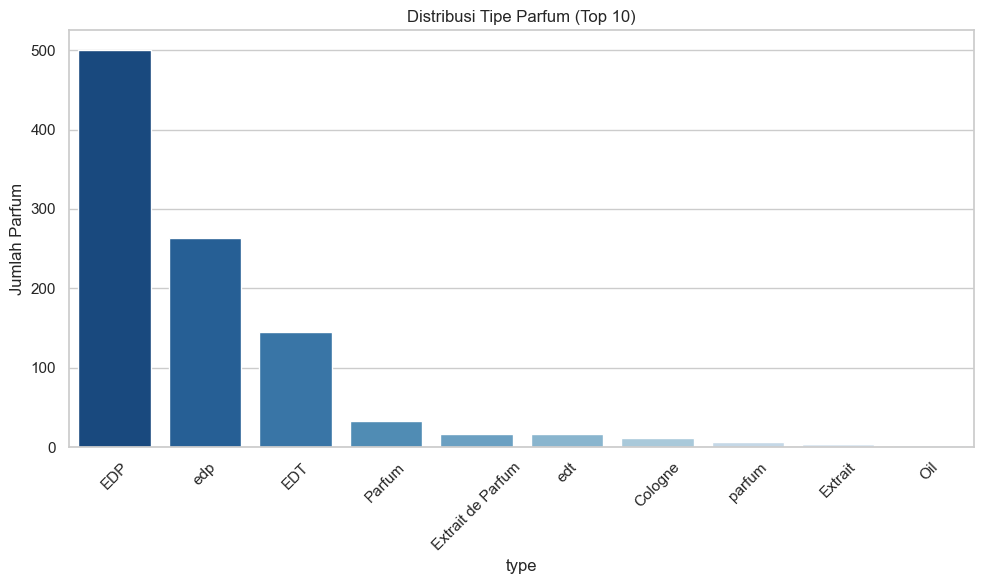

In [45]:
plt.figure(figsize=(10, 6))
top_types = df["type"].value_counts().head(10)
sns.barplot(x=top_types.index, y=top_types.values, palette="Blues_r")
plt.title("Distribusi Tipe Parfum (Top 10)")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Parfum")
plt.tight_layout()
plt.savefig("../data/eda_type.png", dpi=150)
plt.show()

## 2. Distribusi Kategori Aroma

C:\Users\USER\AppData\Local\Temp\ipykernel_15048\4224106328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="Reds_r")


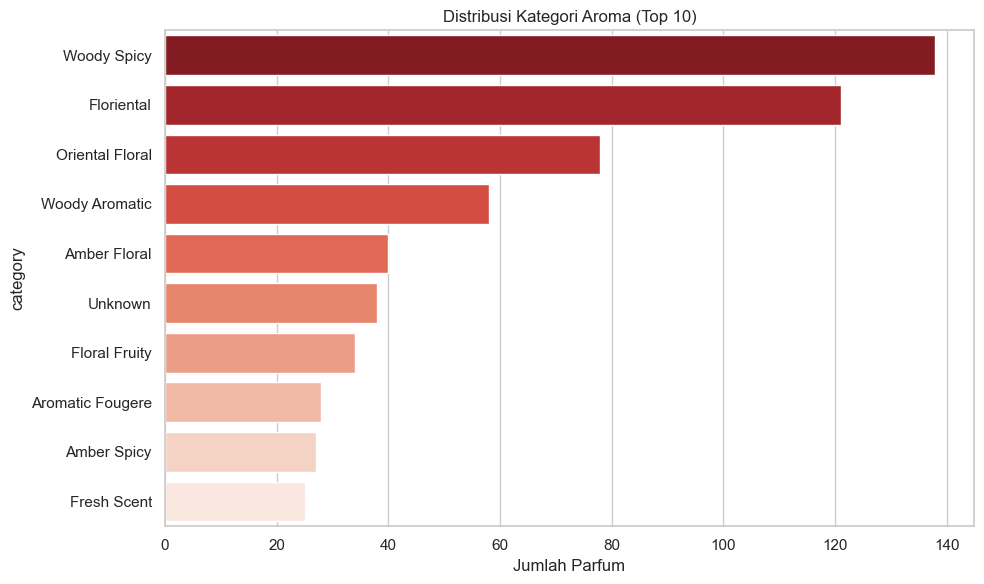

In [46]:
plt.figure(figsize=(10, 6))
top_categories = df["category"].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette="Reds_r")
plt.title("Distribusi Kategori Aroma (Top 10)")
plt.xlabel("Jumlah Parfum")
plt.tight_layout()
plt.savefig("../data/eda_category.png", dpi=150)
plt.show()

## 3. Target Audience

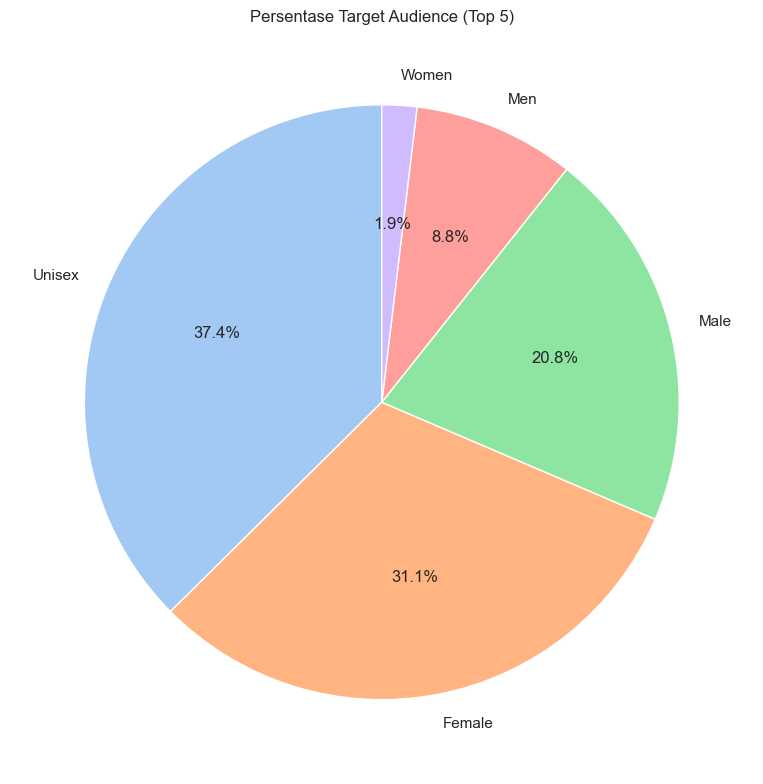

In [47]:
plt.figure(figsize=(8, 8))

# Mengambil 5 kategori terbesar agar pie chart rapi dan tidak ada teks bertumpuk
audience_counts = df["target_audience"].value_counts().head(5)

plt.pie(audience_counts.values, labels=audience_counts.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Persentase Target Audience (Top 5)")
plt.tight_layout()
plt.savefig("../data/eda_audience.png", dpi=150)
plt.show()

## 4. Distribusi Longevity

C:\Users\USER\AppData\Local\Temp\ipykernel_15048\3883931593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=longevity_counts.index, y=longevity_counts.values, palette="Greens_r")


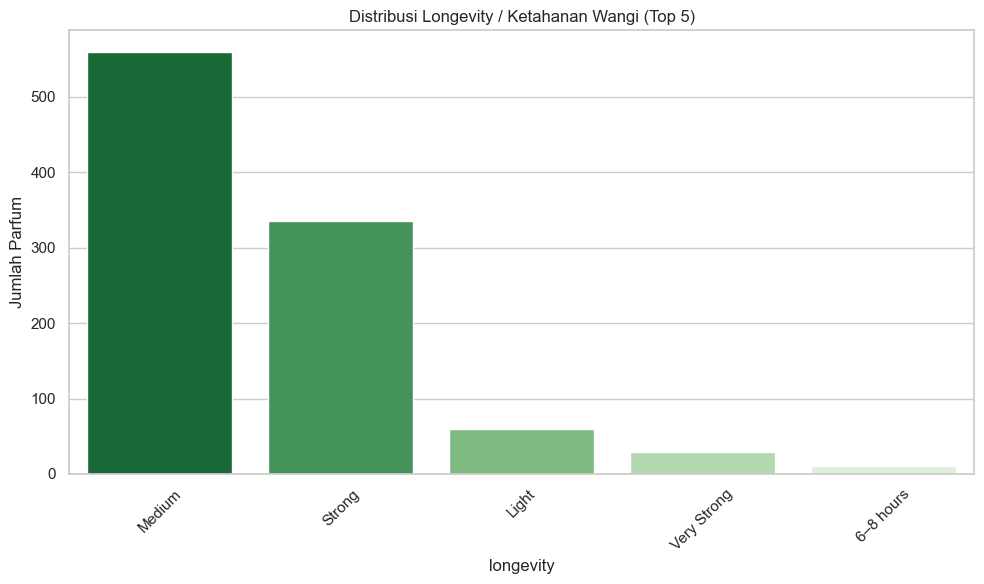

In [48]:
plt.figure(figsize=(10, 6))

# Mengambil 5 kategori terbesar agar bar chart rapi dan tidak ada teks bertumpuk
longevity_counts = df["longevity"].value_counts().head(5)

sns.barplot(x=longevity_counts.index, y=longevity_counts.values, palette="Greens_r")
plt.title("Distribusi Longevity / Ketahanan Wangi (Top 5)")
plt.ylabel("Jumlah Parfum")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../data/eda_longevity.png", dpi=150)
plt.show()

## 5. Top 10 Brand

C:\Users\USER\AppData\Local\Temp\ipykernel_15048\1610733335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")


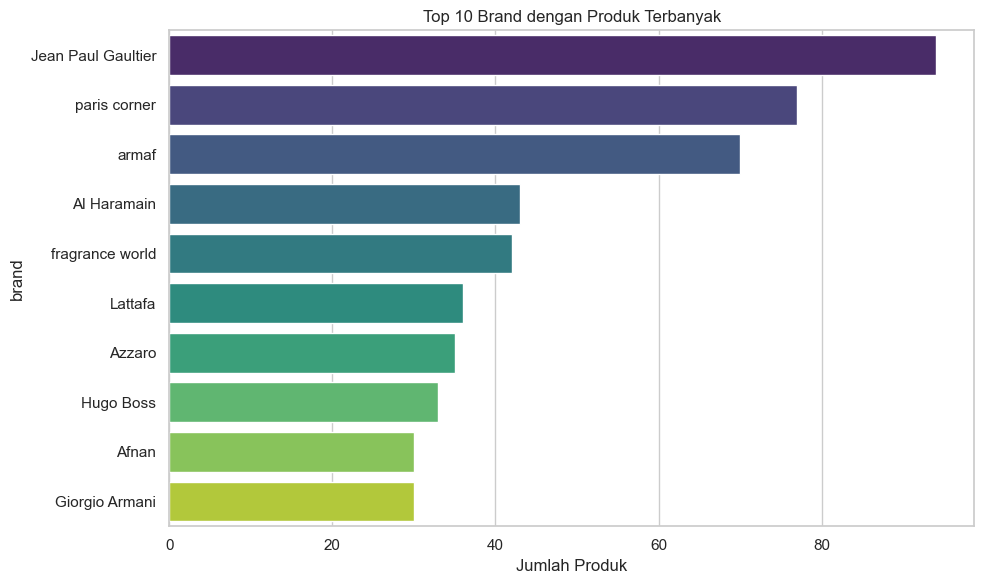

In [49]:
plt.figure(figsize=(10, 6))
top_brands = df["brand"].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 10 Brand dengan Produk Terbanyak")
plt.xlabel("Jumlah Produk")
plt.tight_layout()
plt.savefig("../data/top_brands.png", dpi=150)
plt.show()

## 6. Crosstab Category vs Longevity (Top 10 Kategori Saja)

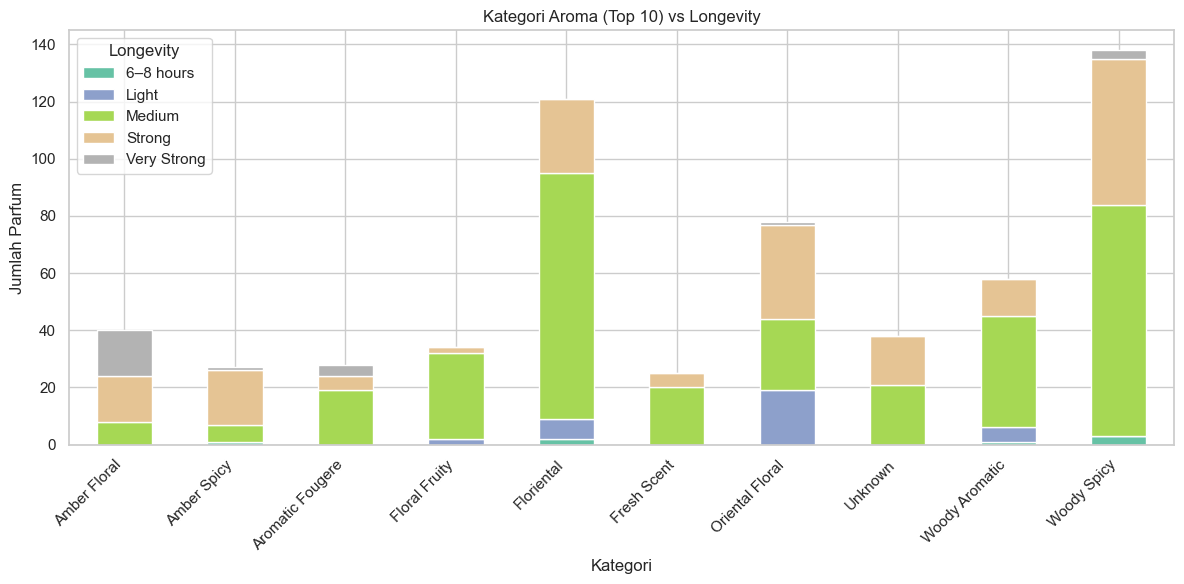

In [50]:
top_10_cats = df['category'].value_counts().head(10).index
df_top_cats = df[df['category'].isin(top_10_cats)]

ct = pd.crosstab(df_top_cats["category"], df_top_cats["longevity"])

ct.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
plt.title("Kategori Aroma (Top 10) vs Longevity")
plt.ylabel("Jumlah Parfum")
plt.xlabel("Kategori")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Longevity')
plt.tight_layout()
plt.savefig("../data/category_longevity.png", dpi=150)
plt.show()